In [1]:
import re
import boto3
import pandas as pd

session = boto3.session.Session()
s3 = session.client("s3")

BUCKET = "dcceew-prod-user-scratch"
USER_PREFIX = "AROAZ6PFZYT4B4C7MNRHV:robotmcgregor"
BASE = f"{USER_PREFIX}/eds"
TILES_BASE = f"{BASE}/tiles"

tile_re = re.compile(r"(p\d{3}r\d{3})")
date_re = re.compile(r"_(\d{8})_")  # 20200611 style

def list_all_objects(bucket, prefix):
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            yield obj

records = []

for obj in list_all_objects(BUCKET, TILES_BASE):
    key = obj["Key"]
    size = obj["Size"]

    if key.endswith("/"):
        continue

    # Extract tile id from anywhere in key
    m_tile = tile_re.search(key)
    tile_id = m_tile.group(1) if m_tile else None

    # Product type by folder
    product_type = None
    if "/fc/" in key:
        product_type = "fc"
    elif "/sr/" in key:
        product_type = "sr"
    elif "/results/" in key:
        product_type = "results"
    else:
        product_type = "other"

    fname = key.split("/")[-1]

    # Date from filename (best-effort)
    m_date = date_re.search(fname)
    date = pd.to_datetime(m_date.group(1)) if m_date else pd.NaT

    # _clr detection
    is_clr = "_clr" in fname

    # normalise to pair raw<->clr siblings:
    # remove only the first occurrence of "_clr" to form a matching base name
    base_no_clr = fname.replace("_clr", "", 1)

    records.append({
        "key": key,
        "fname": fname,
        "tile_id": tile_id,
        "product_type": product_type,
        "date": date,
        "size_bytes": size,
        "is_clr": is_clr,
        "base_no_clr": base_no_clr,
    })

df = pd.DataFrame.from_records(records)

print("Rows:", len(df))
df.head()


Rows: 8204


,key,fname,tile_id,product_type,date,size_bytes,is_clr,base_no_clr
0,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/...,galsfc3_p089r078_20151213_fcm6.tif,p089r078,fc,2015-12-13,861448096,False,galsfc3_p089r078_20151213_fcm6.tif
1,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/...,galsfc3_p089r078_20151213_fcm6_clr.tif,p089r078,fc,2015-12-13,861448096,True,galsfc3_p089r078_20151213_fcm6.tif
2,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/...,galsfc3_p089r078_20160114_fcm6.tif,p089r078,fc,2016-01-14,861448096,False,galsfc3_p089r078_20160114_fcm6.tif
3,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/...,galsfc3_p089r078_20160114_fcm6_clr.tif,p089r078,fc,2016-01-14,861448096,True,galsfc3_p089r078_20160114_fcm6.tif
4,AROAZ6PFZYT4B4C7MNRHV:robotmcgregor/eds/tiles/...,galsfc3_p089r078_20160302_fcm6.tif,p089r078,fc,2016-03-02,861448096,False,galsfc3_p089r078_20160302_fcm6.tif


In [2]:
summary_clr = (
    df[df["product_type"].isin(["sr","fc"])]
      .groupby(["tile_id", "product_type", "is_clr"])
      .agg(
          n_files=("key", "count"),
          total_size_gb=("size_bytes", lambda x: x.sum() / 1e9),
          first_date=("date", "min"),
          last_date=("date", "max"),
      )
      .reset_index()
      .sort_values(["tile_id", "product_type", "is_clr"])
)

summary_clr.head(30)


,tile_id,product_type,is_clr,n_files,total_size_gb,first_date,last_date
0,p089r078,fc,False,188,161.952242,2015-12-13,2025-11-14
1,p089r078,fc,True,188,161.952242,2015-12-13,2025-11-14
2,p089r078,sr,False,188,242.923074,2015-12-13,2025-11-14
3,p089r078,sr,True,188,242.923074,2015-12-13,2025-11-14
4,p089r084,fc,False,145,129.817244,2015-12-13,2025-10-13
5,p089r084,fc,True,145,129.817244,2015-12-13,2025-10-13
6,p089r084,sr,False,145,194.721690,2015-12-13,2025-10-13
7,p089r084,sr,True,145,194.721690,2015-12-13,2025-10-13
8,p090r084,fc,False,138,127.606764,2016-02-06,2025-11-05
9,p090r084,fc,True,138,127.606764,2016-02-06,2025-11-05


In [3]:
pairs = df[df["product_type"].isin(["sr","fc"])].copy()

# For each base_no_clr group, count whether clr/non-clr exists
pair_status = (
    pairs.groupby(["tile_id", "product_type", "base_no_clr"])
         .agg(
             has_raw=("is_clr", lambda x: (~x).any()),
             has_clr=("is_clr", lambda x: (x).any()),
             n_files=("key", "count"),
             min_date=("date", "min"),
             max_date=("date", "max"),
         )
         .reset_index()
)

def classify(row):
    if row["has_raw"] and row["has_clr"]:
        return "both_raw_and_clr"
    if row["has_raw"] and not row["has_clr"]:
        return "raw_only"
    if (not row["has_raw"]) and row["has_clr"]:
        return "clr_only"
    return "unknown"

pair_status["pair_class"] = pair_status.apply(classify, axis=1)

pair_summary = (
    pair_status.groupby(["tile_id", "product_type", "pair_class"])
               .size()
               .reset_index(name="n_groups")
               .sort_values(["tile_id","product_type","pair_class"])
)

pair_summary.head(50)


,tile_id,product_type,pair_class,n_groups
0,p089r078,fc,both_raw_and_clr,188
1,p089r078,sr,both_raw_and_clr,188
2,p089r084,fc,both_raw_and_clr,145
3,p089r084,sr,both_raw_and_clr,145
4,p090r084,fc,both_raw_and_clr,138
5,p090r084,sr,both_raw_and_clr,138
6,p100r082,fc,both_raw_and_clr,208
7,p100r082,sr,both_raw_and_clr,208
8,p104r070,fc,both_raw_and_clr,101
9,p104r070,fc,clr_only,13


In [4]:
from pathlib import Path
import random
import re

TILE = "p089r084"
ROOT = Path("/home/jovyan/scratch/eds/tiles") / TILE

SR_ROOT = ROOT / "sr"
FC_ROOT = ROOT / "fc"

assert SR_ROOT.exists(), f"SR root not found: {SR_ROOT}"
assert FC_ROOT.exists(), f"FC root not found: {FC_ROOT}"

print("Tile:", TILE)
print("SR root:", SR_ROOT)
print("FC root:", FC_ROOT)

# Find all tifs
sr_all = sorted(SR_ROOT.rglob("*.tif"))
fc_all = sorted(FC_ROOT.rglob("*.tif"))

print("SR tif count:", len(sr_all))
print("FC tif count:", len(fc_all))


Tile: p089r084
SR root: /home/jovyan/scratch/eds/tiles/p089r084/sr
FC root: /home/jovyan/scratch/eds/tiles/p089r084/fc
SR tif count: 290
FC tif count: 290


In [5]:
def build_pairs(paths):
    """
    Return list of pairs: (raw_path, clr_path) where both exist.
    Pairing is done by stripping '_clr' from filename.
    """
    by_base = {}
    for p in paths:
        name = p.name
        base = name.replace("_clr", "", 1)  # only remove first occurrence
        by_base.setdefault(base, {"raw": None, "clr": None})
        if "_clr" in name:
            by_base[base]["clr"] = p
        else:
            by_base[base]["raw"] = p

    pairs = []
    for base, d in by_base.items():
        if d["raw"] and d["clr"]:
            pairs.append((d["raw"], d["clr"]))
    return pairs

sr_pairs = build_pairs(sr_all)
fc_pairs = build_pairs(fc_all)

print("SR raw+clr pairs:", len(sr_pairs))
print("FC raw+clr pairs:", len(fc_pairs))

# show a few examples
print("\nExample SR pair:")
if sr_pairs:
    print(" raw:", sr_pairs[0][0])
    print(" clr:", sr_pairs[0][1])

print("\nExample FC pair:")
if fc_pairs:
    print(" raw:", fc_pairs[0][0])
    print(" clr:", fc_pairs[0][1])


SR raw+clr pairs: 145
FC raw+clr pairs: 145

Example SR pair:
 raw: /home/jovyan/scratch/eds/tiles/p089r084/sr/2015/201512/ls89sr_p089r084_20151213_nbart6m6.tif
 clr: /home/jovyan/scratch/eds/tiles/p089r084/sr/2015/201512/ls89sr_p089r084_20151213_nbart6m6_clr.tif

Example FC pair:
 raw: /home/jovyan/scratch/eds/tiles/p089r084/fc/2015/201512/galsfc3_p089r084_20151213_fcm6.tif
 clr: /home/jovyan/scratch/eds/tiles/p089r084/fc/2015/201512/galsfc3_p089r084_20151213_fcm6_clr.tif


In [6]:
random.seed(42)

sr_sample = random.sample(sr_pairs, k=min(5, len(sr_pairs)))
fc_sample = random.sample(fc_pairs, k=min(5, len(fc_pairs)))

print("Selected SR pairs:", len(sr_sample))
for raw, clr in sr_sample:
    print(" ", raw.name, " <-> ", clr.name)

print("\nSelected FC pairs:", len(fc_sample))
for raw, clr in fc_sample:
    print(" ", raw.name, " <-> ", clr.name)


Selected SR pairs: 5
  ls89sr_p089r084_20180204_nbart6m6.tif  <->  ls89sr_p089r084_20180204_nbart6m6_clr.tif
  ls89sr_p089r084_20160419_nbart6m6.tif  <->  ls89sr_p089r084_20160419_nbart6m6_clr.tif
  ls89sr_p089r084_20220215_nbart6m6.tif  <->  ls89sr_p089r084_20220215_nbart6m6_clr.tif
  ls89sr_p089r084_20210401_nbart6m6.tif  <->  ls89sr_p089r084_20210401_nbart6m6_clr.tif
  ls89sr_p089r084_20200820_nbart6m6.tif  <->  ls89sr_p089r084_20200820_nbart6m6_clr.tif

Selected FC pairs: 5
  galsfc3_p089r084_20181119_fcm6.tif  <->  galsfc3_p089r084_20181119_fcm6_clr.tif
  galsfc3_p089r084_20171202_fcm6.tif  <->  galsfc3_p089r084_20171202_fcm6_clr.tif
  galsfc3_p089r084_20250615_fcm6.tif  <->  galsfc3_p089r084_20250615_fcm6_clr.tif
  galsfc3_p089r084_20170727_fcm6.tif  <->  galsfc3_p089r084_20170727_fcm6_clr.tif
  galsfc3_p089r084_20231227_fcm6.tif  <->  galsfc3_p089r084_20231227_fcm6_clr.tif


In [7]:
import numpy as np

def _try_import_rasterio():
    try:
        import rasterio  # noqa
        return True
    except Exception:
        return False

HAS_RASTERIO = _try_import_rasterio()
print("rasterio available:", HAS_RASTERIO)

def read_quicklook(path, max_dim=900):
    """
    Read band 1 and downsample to max_dim for display.
    Returns (array, nodata_value)
    """
    if HAS_RASTERIO:
        import rasterio
        with rasterio.open(path) as ds:
            band = ds.read(1)
            nodata = ds.nodata

            # downsample to max_dim
            h, w = band.shape
            scale = max(h / max_dim, w / max_dim, 1.0)
            out_h = int(h / scale)
            out_w = int(w / scale)

            if out_h != h or out_w != w:
                # re-read at lower resolution
                band = ds.read(
                    1,
                    out_shape=(out_h, out_w),
                    resampling=rasterio.enums.Resampling.nearest,
                )

            return band.astype(np.float32), nodata

    # ---- GDAL fallback ----
    from osgeo import gdal
    ds = gdal.Open(str(path))
    if ds is None:
        raise RuntimeError(f"Cannot open: {path}")
    band = ds.GetRasterBand(1)
    nodata = band.GetNoDataValue()

    arr = band.ReadAsArray().astype(np.float32)
    h, w = arr.shape
    scale = max(h / max_dim, w / max_dim, 1.0)
    out_h = int(h / scale)
    out_w = int(w / scale)
    if out_h != h or out_w != w:
        # cheap decimation (nearest)
        rr = np.linspace(0, h - 1, out_h).astype(int)
        cc = np.linspace(0, w - 1, out_w).astype(int)
        arr = arr[np.ix_(rr, cc)]

    return arr, nodata

def stats_report(arr, nodata):
    if nodata is not None:
        m = arr != nodata
    else:
        # if no nodata defined, treat all finite as valid
        m = np.isfinite(arr)

    valid = arr[m]
    valid_pct = 100.0 * (valid.size / arr.size)

    if valid.size == 0:
        return {
            "valid_pct": valid_pct,
            "min": None,
            "max": None,
            "p2": None,
            "p98": None,
        }

    return {
        "valid_pct": valid_pct,
        "min": float(np.nanmin(valid)),
        "max": float(np.nanmax(valid)),
        "p2": float(np.nanpercentile(valid, 2)),
        "p98": float(np.nanpercentile(valid, 98)),
    }


rasterio available: True


=== SR comparisons ===


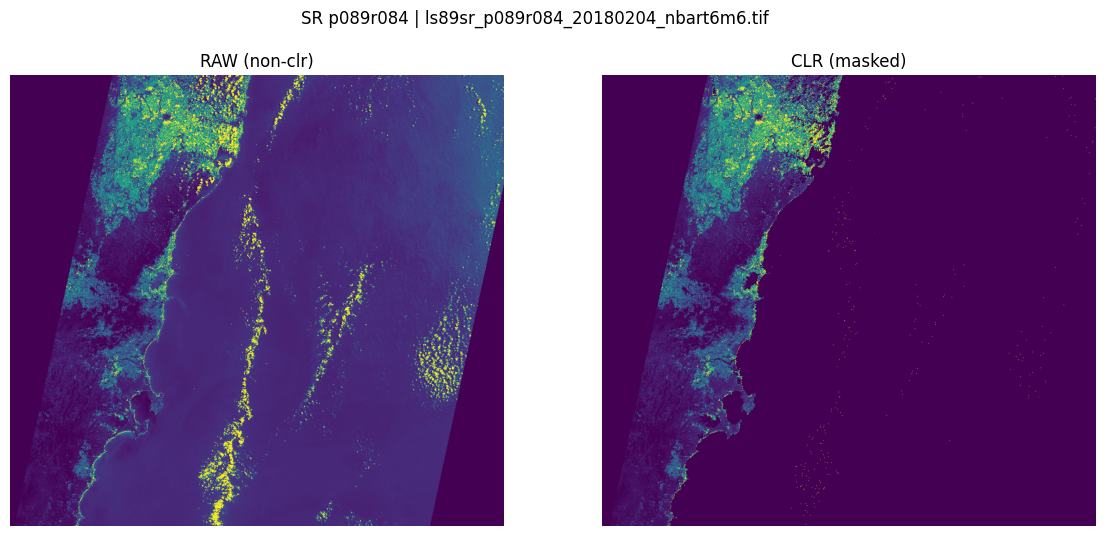

RAW : ls89sr_p089r084_20180204_nbart6m6.tif
  nodata: -999.0
  stats : {'valid_pct': 83.53260429323612, 'min': 6.0, 'max': 8542.0, 'p2': 126.0, 'p98': 1015.0}
CLR : ls89sr_p089r084_20180204_nbart6m6_clr.tif
  nodata: -999.0
  stats : {'valid_pct': 19.474821115161333, 'min': 6.0, 'max': 5967.0, 'p2': 106.0, 'p98': 1145.0}
--------------------------------------------------------------------------------


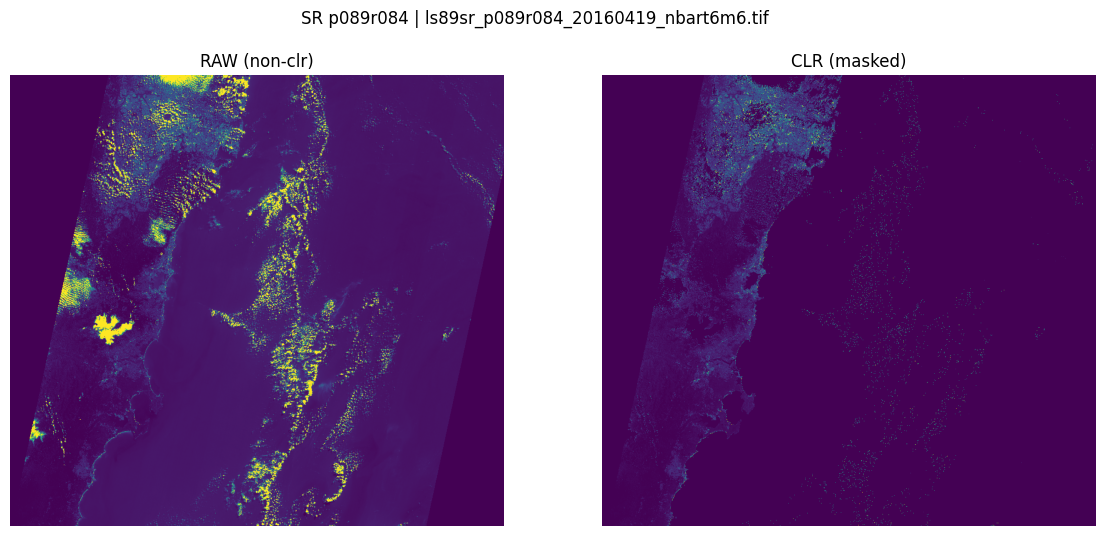

RAW : ls89sr_p089r084_20160419_nbart6m6.tif
  nodata: -999.0
  stats : {'valid_pct': 83.59025246388552, 'min': 1.0, 'max': 10000.0, 'p2': 119.0, 'p98': 2991.0}
CLR : ls89sr_p089r084_20160419_nbart6m6_clr.tif
  nodata: -999.0
  stats : {'valid_pct': 18.327933036317, 'min': 2.0, 'max': 6458.0, 'p2': 94.0, 'p98': 1484.0}
--------------------------------------------------------------------------------


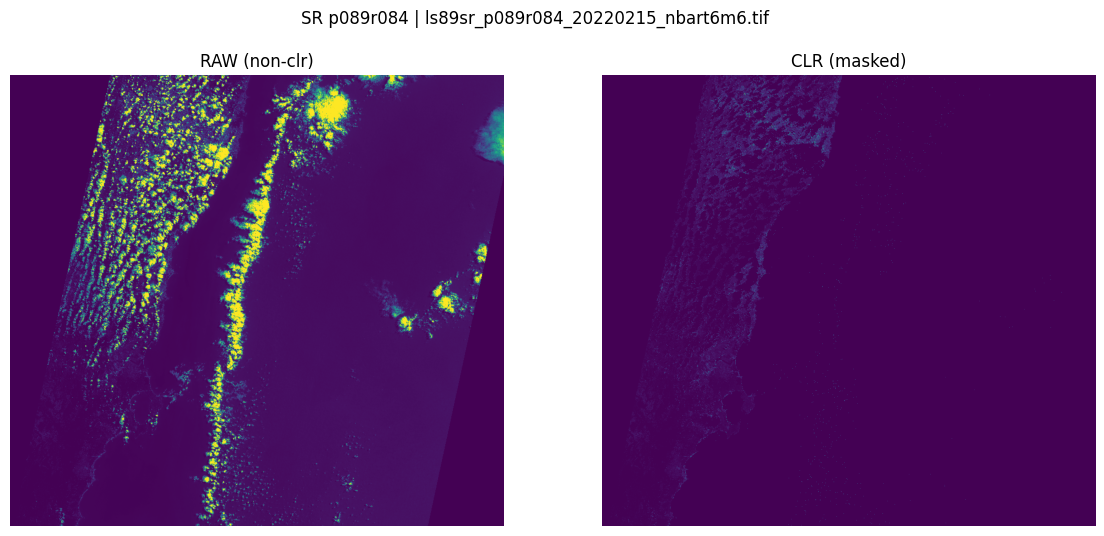

RAW : ls89sr_p089r084_20220215_nbart6m6.tif
  nodata: -999.0
  stats : {'valid_pct': 83.61968408262454, 'min': 64.0, 'max': 10000.0, 'p2': 184.0, 'p98': 6468.0}
CLR : ls89sr_p089r084_20220215_nbart6m6_clr.tif
  nodata: -999.0
  stats : {'valid_pct': 13.422708248953693, 'min': 78.0, 'max': 5454.0, 'p2': 150.0, 'p98': 1423.0}
--------------------------------------------------------------------------------


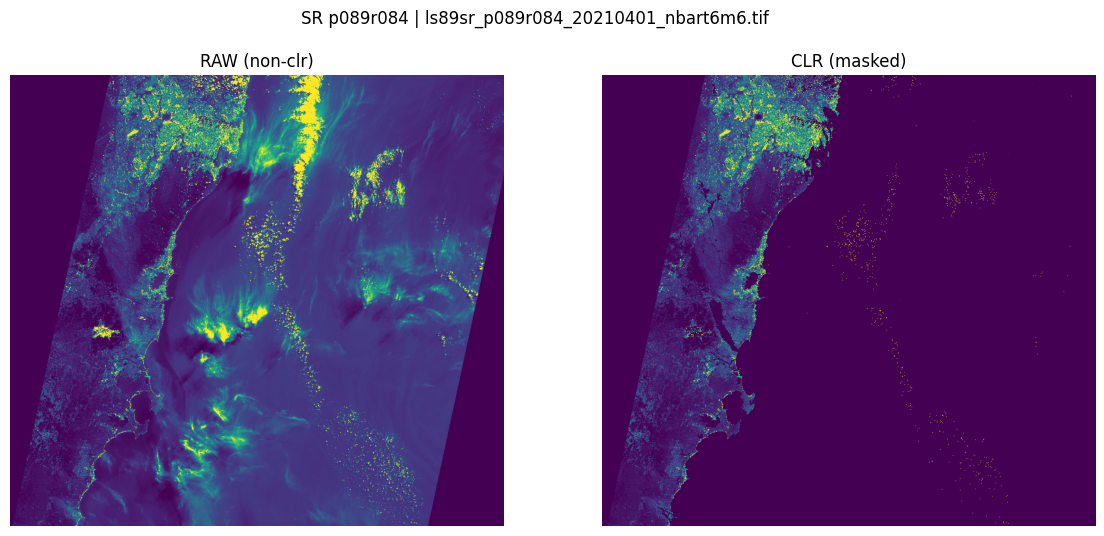

RAW : ls89sr_p089r084_20210401_nbart6m6.tif
  nodata: -999.0
  stats : {'valid_pct': 83.60078304306737, 'min': 1.0, 'max': 10000.0, 'p2': 99.0, 'p98': 1025.0}
CLR : ls89sr_p089r084_20210401_nbart6m6_clr.tif
  nodata: -999.0
  stats : {'valid_pct': 19.564601053057917, 'min': 1.0, 'max': 5881.0, 'p2': 69.0, 'p98': 1123.0}
--------------------------------------------------------------------------------


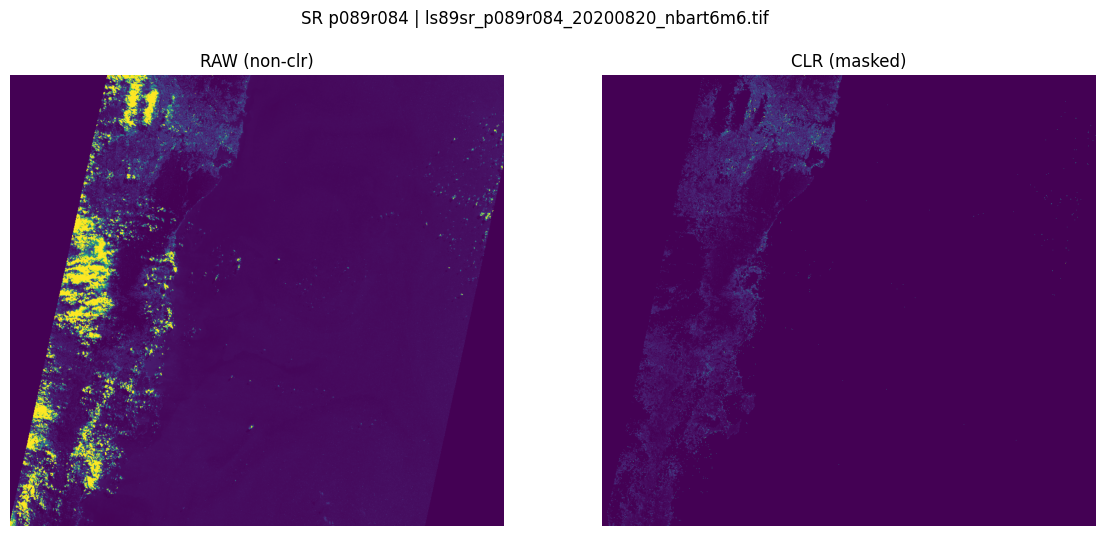

RAW : ls89sr_p089r084_20200820_nbart6m6.tif
  nodata: -999.0
  stats : {'valid_pct': 83.65195085729715, 'min': 1.0, 'max': 10000.0, 'p2': 150.0, 'p98': 4260.0}
CLR : ls89sr_p089r084_20200820_nbart6m6_clr.tif
  nodata: -999.0
  stats : {'valid_pct': 14.774537599567978, 'min': 1.0, 'max': 5650.0, 'p2': 115.0, 'p98': 1175.0}
--------------------------------------------------------------------------------

=== FC comparisons ===


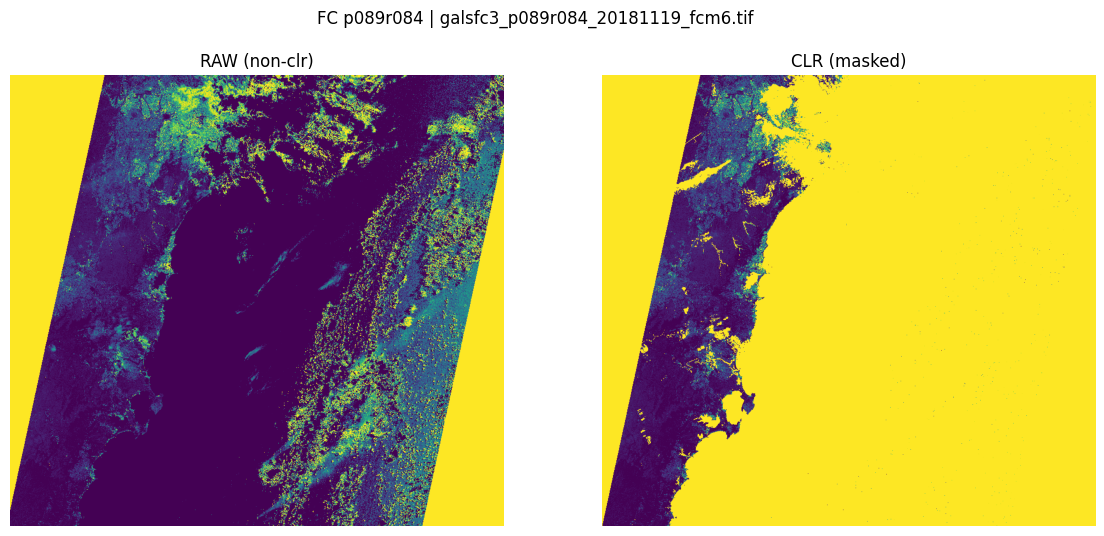

RAW : galsfc3_p089r084_20181119_fcm6.tif
  nodata: 255.0
  stats : {'valid_pct': 83.82503037667071, 'min': 2.0, 'max': 99.0, 'p2': 2.0, 'p98': 75.0}
CLR : galsfc3_p089r084_20181119_fcm6_clr.tif
  nodata: 255.0
  stats : {'valid_pct': 18.767652220872147, 'min': 2.0, 'max': 99.0, 'p2': 2.0, 'p98': 53.0}
--------------------------------------------------------------------------------


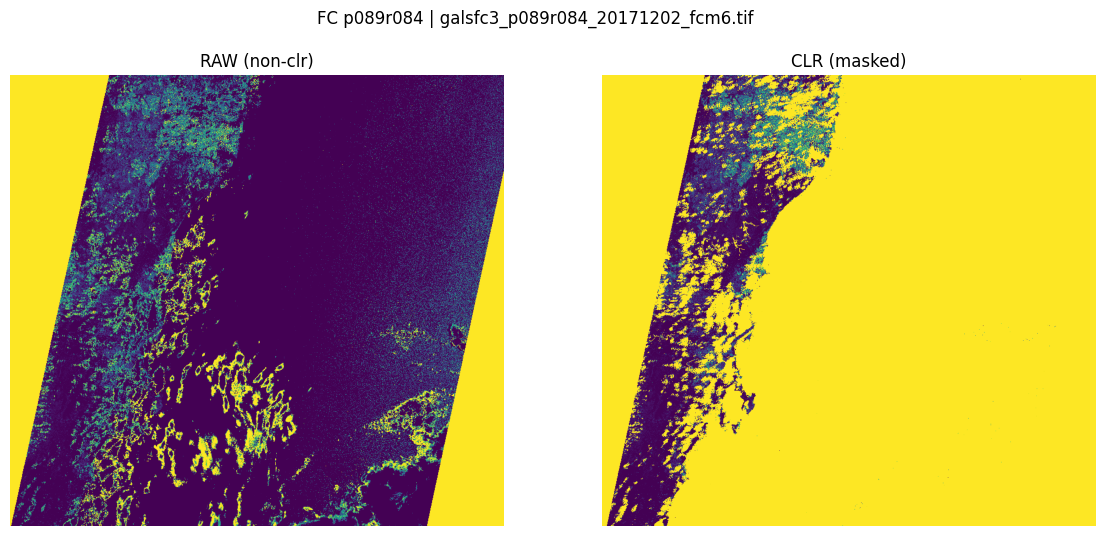

RAW : galsfc3_p089r084_20171202_fcm6.tif
  nodata: 255.0
  stats : {'valid_pct': 83.68300256514108, 'min': 2.0, 'max': 101.0, 'p2': 2.0, 'p98': 84.0}
CLR : galsfc3_p089r084_20171202_fcm6_clr.tif
  nodata: 255.0
  stats : {'valid_pct': 15.118806534359388, 'min': 2.0, 'max': 101.0, 'p2': 2.0, 'p98': 57.0}
--------------------------------------------------------------------------------


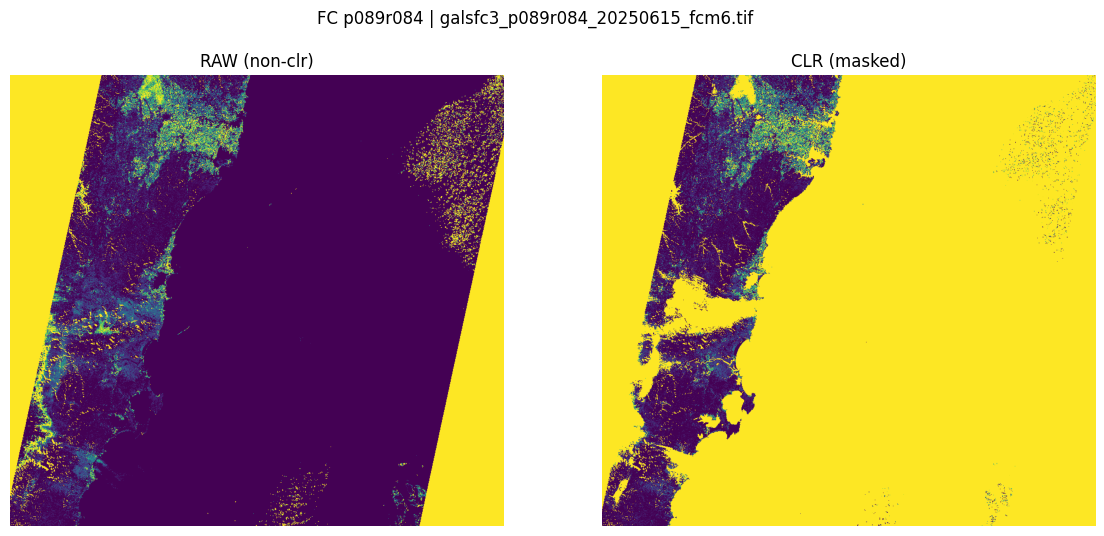

RAW : galsfc3_p089r084_20250615_fcm6.tif
  nodata: 255.0
  stats : {'valid_pct': 83.2058863237478, 'min': 2.0, 'max': 100.0, 'p2': 2.0, 'p98': 64.0}
CLR : galsfc3_p089r084_20250615_fcm6_clr.tif
  nodata: 255.0
  stats : {'valid_pct': 18.959362764952072, 'min': 2.0, 'max': 99.0, 'p2': 2.0, 'p98': 88.0}
--------------------------------------------------------------------------------


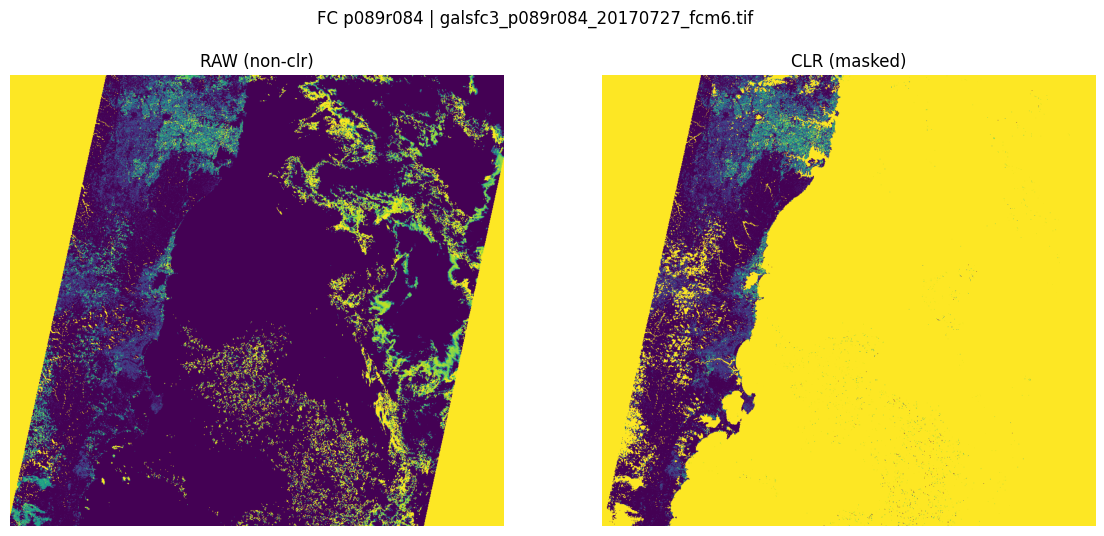

RAW : galsfc3_p089r084_20170727_fcm6.tif
  nodata: 255.0
  stats : {'valid_pct': 83.42729850141758, 'min': 2.0, 'max': 103.0, 'p2': 2.0, 'p98': 97.0}
CLR : galsfc3_p089r084_20170727_fcm6_clr.tif
  nodata: 255.0
  stats : {'valid_pct': 19.628459565276092, 'min': 2.0, 'max': 99.0, 'p2': 2.0, 'p98': 93.0}
--------------------------------------------------------------------------------


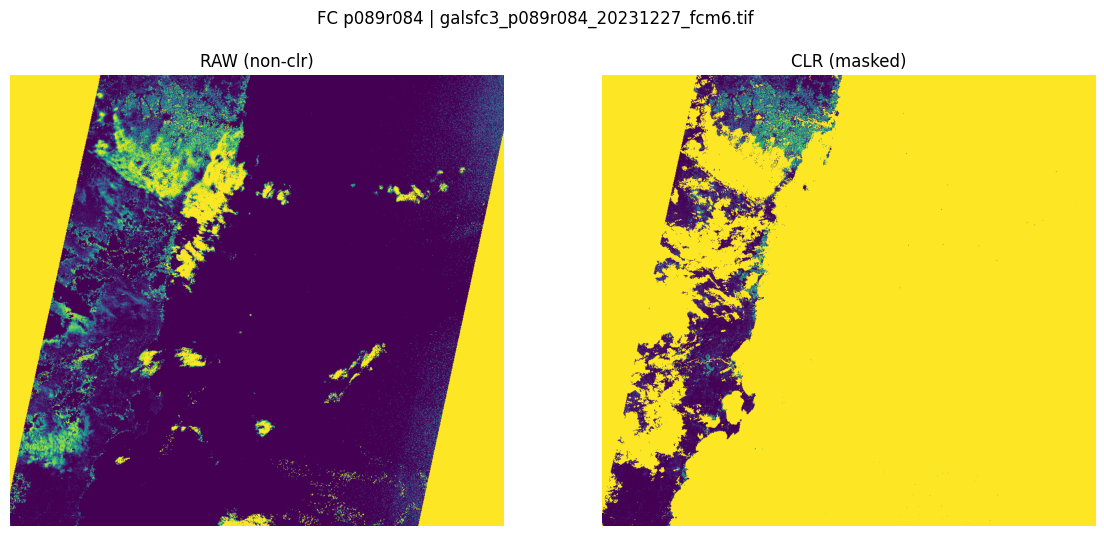

RAW : galsfc3_p089r084_20231227_fcm6.tif
  nodata: 255.0
  stats : {'valid_pct': 83.89172404482247, 'min': 2.0, 'max': 98.0, 'p2': 2.0, 'p98': 77.0}
CLR : galsfc3_p089r084_20231227_fcm6_clr.tif
  nodata: 255.0
  stats : {'valid_pct': 12.71175914675307, 'min': 2.0, 'max': 98.0, 'p2': 2.0, 'p98': 59.0}
--------------------------------------------------------------------------------


In [8]:
import matplotlib.pyplot as plt

def show_pair(raw_path, clr_path, title):
    raw, raw_nd = read_quicklook(raw_path)
    clr, clr_nd = read_quicklook(clr_path)

    raw_stats = stats_report(raw, raw_nd)
    clr_stats = stats_report(clr, clr_nd)

    # Use a common display stretch based on combined valid pixels (p2..p98)
    def valid_vals(a, nd):
        if nd is not None:
            m = a != nd
        else:
            m = np.isfinite(a)
        return a[m]

    vv = np.concatenate([valid_vals(raw, raw_nd), valid_vals(clr, clr_nd)])
    if vv.size > 0:
        vmin = np.percentile(vv, 2)
        vmax = np.percentile(vv, 98)
    else:
        vmin, vmax = None, None

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(raw, vmin=vmin, vmax=vmax)
    axes[0].set_title("RAW (non-clr)")
    axes[0].axis("off")

    axes[1].imshow(clr, vmin=vmin, vmax=vmax)
    axes[1].set_title("CLR (masked)")
    axes[1].axis("off")

    fig.suptitle(title, y=0.98)
    plt.show()

    print("RAW :", raw_path.name)
    print("  nodata:", raw_nd)
    print("  stats :", raw_stats)
    print("CLR :", clr_path.name)
    print("  nodata:", clr_nd)
    print("  stats :", clr_stats)
    print("-" * 80)

# --- SR examples ---
print("=== SR comparisons ===")
for raw, clr in sr_sample:
    show_pair(raw, clr, title=f"SR {TILE} | {raw.name}")

# --- FC examples ---
print("\n=== FC comparisons ===")
for raw, clr in fc_sample:
    show_pair(raw, clr, title=f"FC {TILE} | {raw.name}")
